In [204]:
pip install tensorflow pandas numpy matplotlib scikit-learn


Note: you may need to restart the kernel to use updated packages.


In [205]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input, LSTM, Dense, Dropout

In [206]:
df = pd.read_csv(
    "household_power_consumption.txt",
    sep=";",
    low_memory=False
)

In [207]:
print(df.head())


         Date      Time Global_active_power Global_reactive_power  Voltage  \
0  16/12/2006  17:24:00               4.216                 0.418  234.840   
1  16/12/2006  17:25:00               5.360                 0.436  233.630   
2  16/12/2006  17:26:00               5.374                 0.498  233.290   
3  16/12/2006  17:27:00               5.388                 0.502  233.740   
4  16/12/2006  17:28:00               3.666                 0.528  235.680   

  Global_intensity Sub_metering_1 Sub_metering_2  Sub_metering_3  
0           18.400          0.000          1.000            17.0  
1           23.000          0.000          1.000            16.0  
2           23.000          0.000          2.000            17.0  
3           23.000          0.000          1.000            17.0  
4           15.800          0.000          1.000            17.0  


In [208]:
print(df.isnull().sum())

Date                         0
Time                         0
Global_active_power          0
Global_reactive_power        0
Voltage                      0
Global_intensity             0
Sub_metering_1               0
Sub_metering_2               0
Sub_metering_3           25979
dtype: int64


In [209]:
df.shape

(2075259, 9)

In [210]:
df["Datetime"] = pd.to_datetime(
    df["Date"] + " " + df["Time"],
    format="%d/%m/%Y %H:%M:%S"
)

df = df.drop(columns=["Date", "Time"])

In [211]:
print(df.info())


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2075259 entries, 0 to 2075258
Data columns (total 8 columns):
 #   Column                 Dtype         
---  ------                 -----         
 0   Global_active_power    object        
 1   Global_reactive_power  object        
 2   Voltage                object        
 3   Global_intensity       object        
 4   Sub_metering_1         object        
 5   Sub_metering_2         object        
 6   Sub_metering_3         float64       
 7   Datetime               datetime64[ns]
dtypes: datetime64[ns](1), float64(1), object(6)
memory usage: 126.7+ MB
None


In [212]:
df.replace("?", np.nan, inplace=True)

In [213]:
cols = [
    "Global_active_power",
    "Global_reactive_power",
    "Voltage",
    "Global_intensity",
    "Sub_metering_1",
    "Sub_metering_2",
    "Sub_metering_3"
]

for col in cols:
    df[col] = pd.to_numeric(df[col])

In [214]:
df = df.ffill()

In [215]:
df.isna().sum()

Global_active_power      0
Global_reactive_power    0
Voltage                  0
Global_intensity         0
Sub_metering_1           0
Sub_metering_2           0
Sub_metering_3           0
Datetime                 0
dtype: int64

In [216]:
df.columns.value_counts()

Global_active_power      1
Global_reactive_power    1
Voltage                  1
Global_intensity         1
Sub_metering_1           1
Sub_metering_2           1
Sub_metering_3           1
Datetime                 1
Name: count, dtype: int64

In [217]:
df = df.sort_values("Datetime")

In [218]:
df.set_index("Datetime", inplace=True)

In [219]:
df.dtypes

Global_active_power      float64
Global_reactive_power    float64
Voltage                  float64
Global_intensity         float64
Sub_metering_1           float64
Sub_metering_2           float64
Sub_metering_3           float64
dtype: object

In [220]:
df.head()

,Global_active_power,Global_reactive_power,Voltage,Global_intensity,Sub_metering_1,Sub_metering_2,Sub_metering_3
Datetime,,,,,,,
2006-12-16 17:24:00,4.216,0.418,234.84,18.4,0.0,1.0,17.0
2006-12-16 17:25:00,5.360,0.436,233.63,23.0,0.0,1.0,16.0
2006-12-16 17:26:00,5.374,0.498,233.29,23.0,0.0,2.0,17.0
2006-12-16 17:27:00,5.388,0.502,233.74,23.0,0.0,1.0,17.0
2006-12-16 17:28:00,3.666,0.528,235.68,15.8,0.0,1.0,17.0


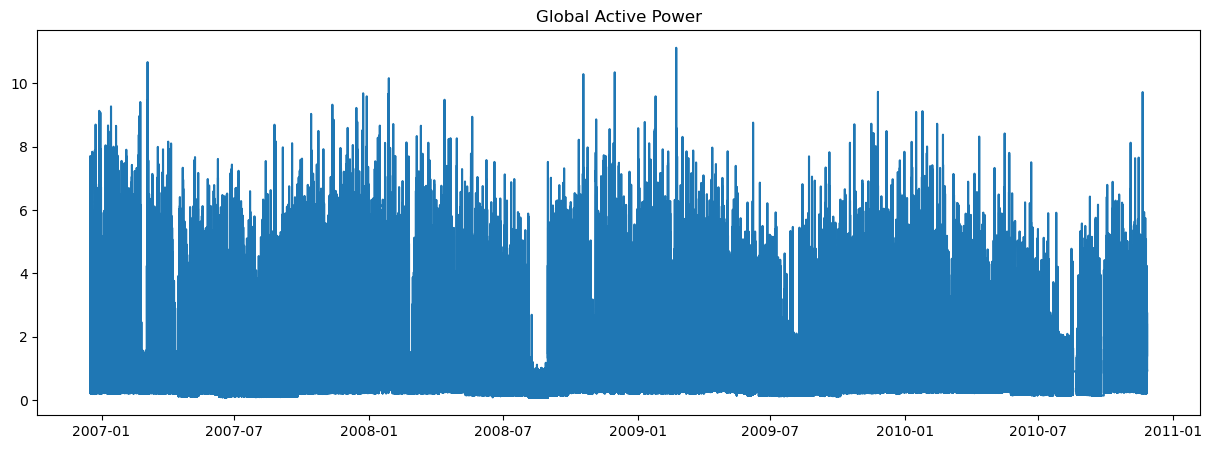

In [221]:
plt.figure(figsize=(15,5))
plt.plot(df["Global_active_power"])
plt.title("Global Active Power")
plt.show()

In [222]:
features = [
    'Global_active_power',
    'Global_reactive_power',
    'Voltage',
    'Global_intensity',
    'Sub_metering_1',
    'Sub_metering_2',
    'Sub_metering_3'
]
df_small = df.iloc[:100000].copy()
data = df_small[features]


In [223]:
scaler = MinMaxScaler()

scaled_data = scaler.fit_transform(data)

print(scaled_data.shape)

(100000, 7)


In [224]:
sequence_length = 60
target_index = 0      # Global_active_power

In [225]:
def create_sequences(data, seq_length, target_col):
    X = []
    y = []

    for i in range(seq_length, len(data)):
        X.append(data[i-seq_length:i])
        y.append(data[i, target_col])

    return np.array(X), np.array(y)

In [226]:
X, y = create_sequences(
    scaled_data,
    sequence_length,
    target_index
)

print(X.shape)
print(y.shape)

(99940, 60, 7)
(99940,)


In [227]:
train_size = int(len(X) * 0.8)

X_train = X[:train_size]
X_test = X[train_size:]

y_train = y[:train_size]
y_test = y[train_size:]

print(X_train.shape)
print(X_test.shape)

(79952, 60, 7)
(19988, 60, 7)


In [228]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input, LSTM, Dense, Dropout

model = Sequential([
    Input(shape=(60, 7)),

    LSTM(64, return_sequences=True),
    Dropout(0.2),

    LSTM(32),
    Dropout(0.2),

    Dense(16, activation='relu'),
    Dense(1)
])

In [229]:
model.compile(
    optimizer='adam',
    loss='mse',
    metrics=['mae']
)

In [230]:
model.summary()

Model: "sequential_6"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_12 (LSTM)                  │ (None, 60, 64)         │        18,432 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_12 (Dropout)            │ (None, 60, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_13 (LSTM)                  │ (None, 32)             │        12,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_13 (Dropout)            │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_12 (Dense)                │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_13 (Dense)                │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 31,393 (122.63 KB)

 Trainable params: 31,393 (122.63 KB)

 Non-trainable params: 0 (0.00 B)

In [231]:
history = model.fit(
    X_train,
    y_train,
    epochs=20,
    batch_size=64,
    validation_data=(X_test, y_test),
    shuffle=False,
    verbose=1
)

Epoch 1/20
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 66s 50ms/step - loss: 0.0056 - mae: 0.0476 - val_loss: 0.0023 - val_mae: 0.0247
Epoch 2/20
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 88s 70ms/step - loss: 0.0031 - mae: 0.0341 - val_loss: 0.0017 - val_mae: 0.0212
Epoch 3/20
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 94s 75ms/step - loss: 0.0025 - mae: 0.0293 - val_loss: 0.0014 - val_mae: 0.0170
Epoch 4/20
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 101s 80ms/step - loss: 0.0022 - mae: 0.0269 - val_loss: 0.0014 - val_mae: 0.0170
Epoch 5/20
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 101s 81ms/step - loss: 0.0021 - mae: 0.0268 - val_loss: 0.0014 - val_mae: 0.0180
Epoch 6/20
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 100s 80ms/step - loss: 0.0021 - mae: 0.0260 - val_loss: 0.0014 - val_mae: 0.0175
Epoch 7/20
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 83s 66ms/step - loss: 0.0020 - mae: 0.0257 - val_loss: 0.0014 - val_mae: 0.0168
Epoch 8/20
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 89s 71ms/step - loss: 0.0019 - mae: 0.0251 - val_loss: 0.0014 - val_mae: 0.0174
Epoch 9/20
1250/1250 

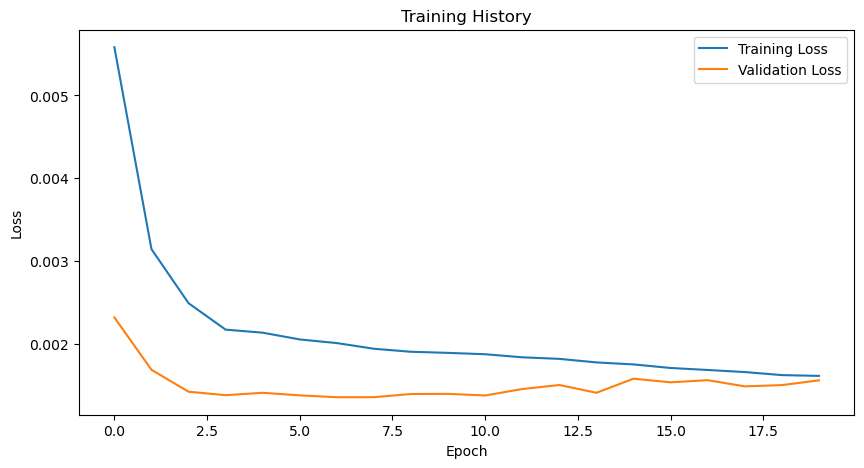

In [232]:
plt.figure(figsize=(10,5))

plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')

plt.title("Training History")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()

plt.show()

In [233]:
predictions = model.predict(X_test)

625/625 ━━━━━━━━━━━━━━━━━━━━ 5s 8ms/step


In [234]:
import numpy as np

pred_dummy = np.zeros((len(predictions), len(features)))
actual_dummy = np.zeros((len(y_test), len(features)))

pred_dummy[:, 0] = predictions.flatten()
actual_dummy[:, 0] = y_test.flatten()

predictions = scaler.inverse_transform(pred_dummy)[:, 0]
actual = scaler.inverse_transform(actual_dummy)[:, 0]

In [235]:
from sklearn.metrics import mean_squared_error
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import r2_score

rmse = np.sqrt(mean_squared_error(actual, predictions))
mae = mean_absolute_error(actual, predictions)
r2 = r2_score(actual, predictions)

print(f"RMSE : {rmse:.3f}")
print(f"MAE  : {mae:.3f}")
print(f"R²   : {r2:.4f}")

RMSE : 0.364
MAE  : 0.210
R²   : 0.9302


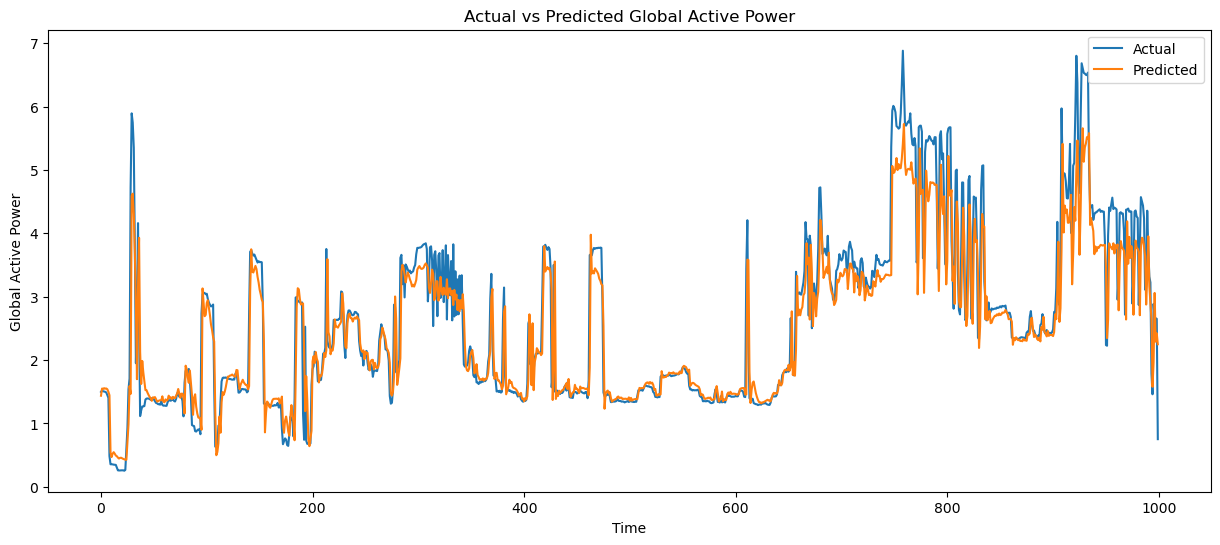

In [236]:
plt.figure(figsize=(15,6))

plt.plot(actual[:1000], label='Actual')
plt.plot(predictions[:1000], label='Predicted')

plt.title("Actual vs Predicted Global Active Power")
plt.xlabel("Time")
plt.ylabel("Global Active Power")
plt.legend()

plt.show()

In [237]:
model.save("power_consumption_lstm.keras")